# PFC: Phase Diagram


## One Mode Approximation
[1] Emdadi, A., Asle Zaeem, M. & Asadi, E. Revisiting phase diagrams of two-mode phase-field crystal models. Computational Materials Science 123, 139–147 (2016).

Assuming that the system is in crystalline state and the average value of the density is $\bar{n}$, then the functional form of a periodic density can be written in terms of reciprocal lattice vectors (RLVs), $\vec{k}$, and their amplitudes $A_{\vec{k}}$ by:
\begin{align}
n_{phase} = \bar{n}+\sum_{\vec{k}}A_{\vec{k}}e^{i\vec{k}\cdot\vec{r}}+c.c.
\end{align}
The dimensionless density profiles in the solid state for square, triangular, stripe lattice structures in PFC model by considering the first wavelength amplitudes are:
\begin{align}
n_{sq}&=\bar{n}+A\left(\cos qx+\cos qy\right); \left(q=1\right) \nonumber \\
&=\bar{n}+A\left(\cos x+\cos y\right)\\
n_{tri}&=\bar{n}+A\left(\cos qx \cos \frac{qy}{\sqrt{3}}+\frac{1}{2}\cos\frac{2qy}{\sqrt{3}}\right); \left(q=\frac{\sqrt{3}}{2}\right) \nonumber \\
&= \bar{n}+A\left(\cos \frac{\sqrt{3}}{2}x \cos \frac{1}{2}y+\frac{1}{2}\cos y\right)\\
n_{str}&=\bar{n}+A\cos qx=\bar{n}+A\cos x; \left(q=1\right)
\end{align}

## the Simplest PFC Model

Take the simplest PFC model for example,

\begin{align}
F[n]=\int\left[\varepsilon \frac{n^2}{2}+\frac{n^4}{4}+\frac{n}{2}\left(1+\nabla^2\right)^2n\right]dx
\end{align}

Substitute the "one mode approximation" to the integrand (Mathematica):
![gsimple](./images/gsimple.png "gsimple")

Integrate per period area and divided by the area to get the free energy density, minimize the free energy density in order to evaluate amplitude $A$.

![Asimple](./images/Asimple.png "Asimple")

Adopt the common tangent method to get the phase field order parameter value in equilibrium:

![csimple](./images/csimple.png "csimple")

The phase diagram can be calculated:

![pdsimple](./images/pdsimple.png "pdsimple")

## the Dynamical Equation

The conserved order parameter evolves as:

\begin{align}
\frac{\partial n}{\partial t} &= M\nabla^2\frac{\delta F}{\delta n} \\
&\Downarrow \nonumber \\
\frac{\partial n}{\partial t} &= M\nabla^2\left[\varepsilon n + n^3 + (1+2\nabla^2+\nabla^4)n\right]
\end{align}

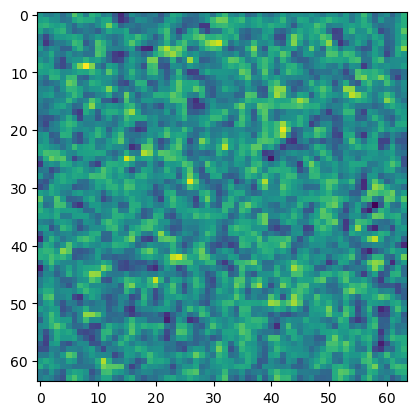

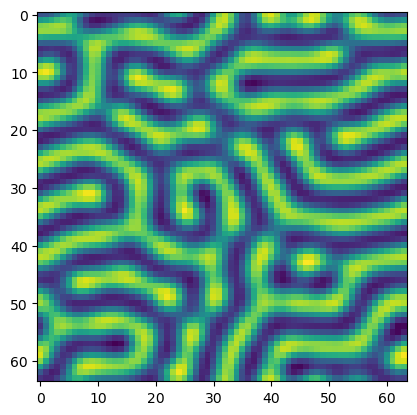

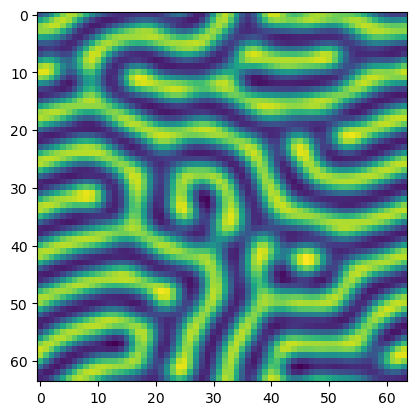

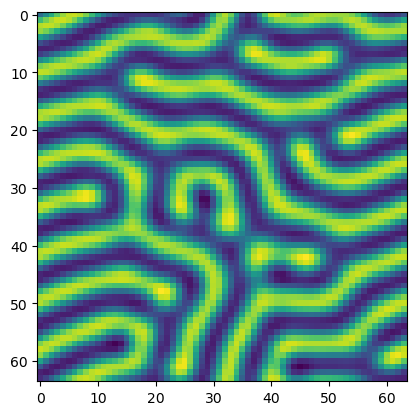

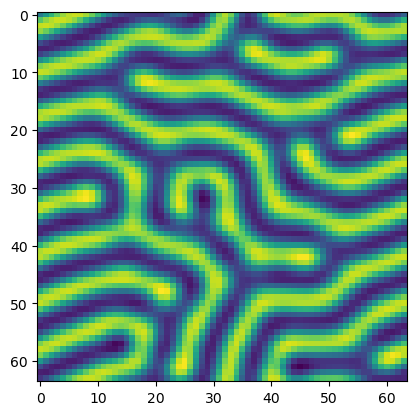

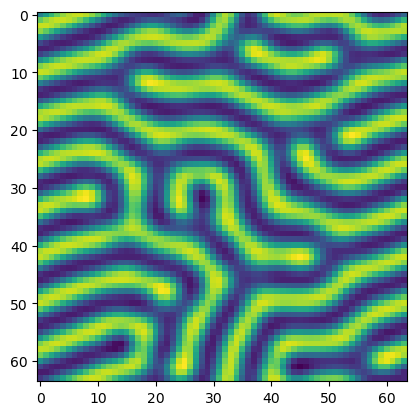

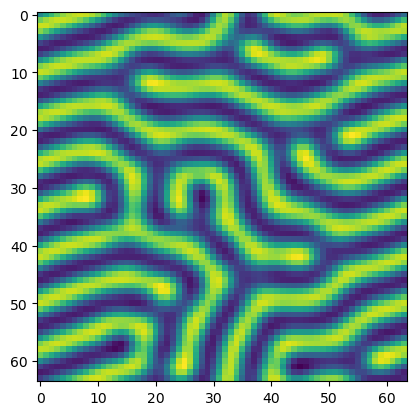

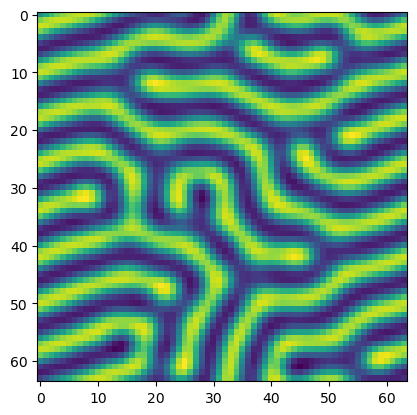

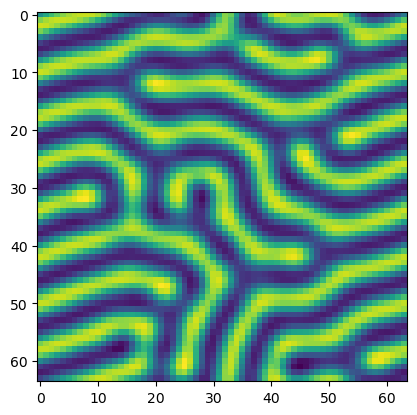

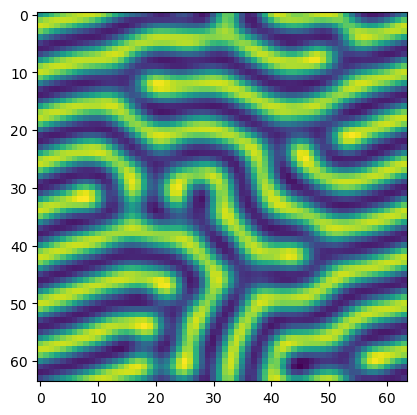

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage
def calLap1(phi, dx):
    phi_ipj0 = np.roll(phi, 1, axis=0) # phi_ipj0=phi(i+1,j)
    phi_imj0 = np.roll(phi, -1, axis=0) # phi_imj0=phi(i-1,j)
    phi_i0jp = np.roll(phi, 1, axis=1)
    phi_i0jm = np.roll(phi, -1, axis=1)
    phi_ipjp = np.roll(phi, (1,1), axis=(0,1))
    phi_ipjm = np.roll(phi, (1,-1), axis=(0,1))
    phi_imjp = np.roll(phi, (-1,1), axis=(0,1))
    phi_imjm = np.roll(phi, (-1,-1), axis=(0,1))
    phi_lap = (0.5*(phi_ipj0+phi_imj0+phi_i0jp+phi_i0jm)+0.25*(phi_ipjp+phi_imjp+phi_ipjm+phi_imjm)-3*phi)/(dx**2.0)
    return(phi_lap)
# def calLap2(n, dx): 这个函数的稳定性很差...
#     lap = ndimage.laplace(n)/(dx**2)
#     return(lap)
def calDyn(epsl, M, dx, n):
    fun = (epsl+1)*n + n**3 + 2*calLap1(n,dx) + calLap1(calLap1(n,dx),dx)
    dyn = calLap1(M*fun, dx)
    return(dyn)
epsl = -0.6
nbar = -0.05
M = 1.0
dt = 0.005
a = 2*np.pi
dx = a/8.0 # the larger, the stabler
Lx = Ly = 8*a
Nx = int(Lx/dx)
Ny = int(Ly/dx)
xlst = np.arange(Nx)*dx
ylst = np.arange(Ny)*dx
[xmat, ymat] = np.meshgrid(xlst, ylst,indexing='ij')
A = 0.1
# ntr_all = nbar + A*(np.cos(np.sqrt(3)/2*xmat)*np.cos(0.5*ymat)+0.5*np.cos(ymat))
nlq = np.random.normal(nbar, 1e-2, (Nx,Ny))
n = nlq
nstep = 50000
ndump = 5000
for istep in range(nstep):
    n = n+dt*calDyn(epsl, M, dx, n)
    if (istep%ndump == 0):
        plt.figure()
        plt.imshow(n)